Cell 1: Imports & Configuration

In [2]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from wordcloud import WordCloud
from collections import Counter
import warnings
# Configuration
warnings.filterwarnings('ignore')
%matplotlib inline
sns.set(style="whitegrid")


Cell 2: Load Data

In [4]:
# Load the dataset
# Assuming the notebook is in a 'notebooks' folder and data is in 'data' folder
# Adjust the path if your notebook is in the root directory: 'data/Spam_SMS.csv'
file_path = '../data/Spam_SMS.csv'

try:
    # We use header=0 because the file has a header row ("Class,Message")
    df = pd.read_csv(file_path, sep=',', names=["class", "message"], header=0, encoding='utf-8')
    print(f"Data loaded. Shape: {df.shape}")
except FileNotFoundError:
    print("Error: File not found. Please check the path.")

Data loaded. Shape: (5574, 2)


Cell 3: Basic Inspection

In [6]:
# Display first 5 rows
display(df.head())

# Check for missing values and data types
print("\n--- DataFrame Info ---")
print(df.info())

# Check for duplicates
duplicates = df.duplicated().sum()
print(f"\nExample Duplicates: {duplicates}")

# Remove duplicates to ensure clean analysis
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print(f"✅ Duplicates removed. New shape: {df.shape}")

,class,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."



--- DataFrame Info ---
<class 'pandas.core.frame.DataFrame'>
Index: 5159 entries, 0 to 5573
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   class    5159 non-null   object
 1   message  5159 non-null   object
dtypes: object(2)
memory usage: 120.9+ KB
None

Example Duplicates: 0


Cell 4: Target Class Distribution

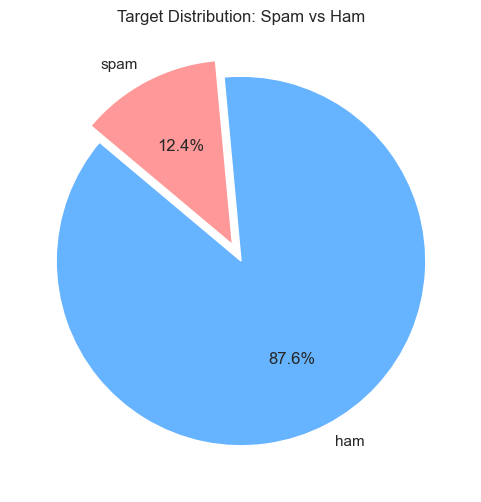

Observation: The dataset is imbalanced. 'Ham' messages significantly outnumber 'Spam' messages.


In [8]:
# Analyze the balance between 'spam' and 'ham'
class_counts = df['class'].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(class_counts, labels=class_counts.index, autopct='%1.1f%%', startangle=140, colors=['#66b3ff','#ff9999'], explode=(0, 0.1))
plt.title('Target Distribution: Spam vs Ham')
plt.show()

print("Observation: The dataset is imbalanced. 'Ham' messages significantly outnumber 'Spam' messages.")

Cell 5: Feature Engineering (Message Length)

In [9]:
# Create a new feature 'length' representing the number of characters in the message
df['length'] = df['message'].apply(len)

display(df[['class', 'message', 'length']].head())

# Statistical summary of length by class
print("\n--- Length Statistics ---")
print(df.groupby('class')['length'].describe())

,class,message,length
0,ham,"Go until jurong point, crazy.. Available only ...",111
1,ham,Ok lar... Joking wif u oni...,29
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,ham,U dun say so early hor... U c already then say...,49
4,ham,"Nah I don't think he goes to usf, he lives aro...",61



--- Length Statistics ---
        count        mean        std   min    25%    50%    75%    max
class                                                                 
ham    4518.0   70.861000  56.584513   2.0   34.0   53.0   91.0  910.0
spam    641.0  137.413417  29.998996  13.0  131.0  148.0  157.0  223.0


Cell 6: Visualizing Message Length

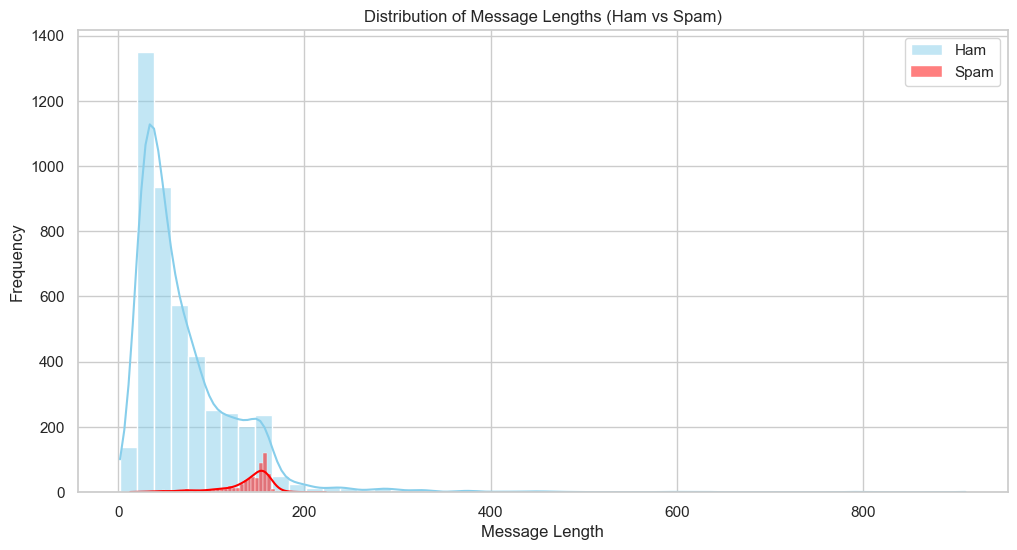

Observation: Spam messages tend to be longer than normal (ham) messages.


In [10]:
# Plot histogram for message lengths
plt.figure(figsize=(12, 6))

sns.histplot(df[df['class'] == 'ham']['length'], bins=50, kde=True, color='skyblue', label='Ham')
sns.histplot(df[df['class'] == 'spam']['length'], bins=50, kde=True, color='red', label='Spam')

plt.title('Distribution of Message Lengths (Ham vs Spam)')
plt.xlabel('Message Length')
plt.ylabel('Frequency')
plt.legend()
plt.show()

print("Observation: Spam messages tend to be longer than normal (ham) messages.")

Cell 7: WordCloud Analysis

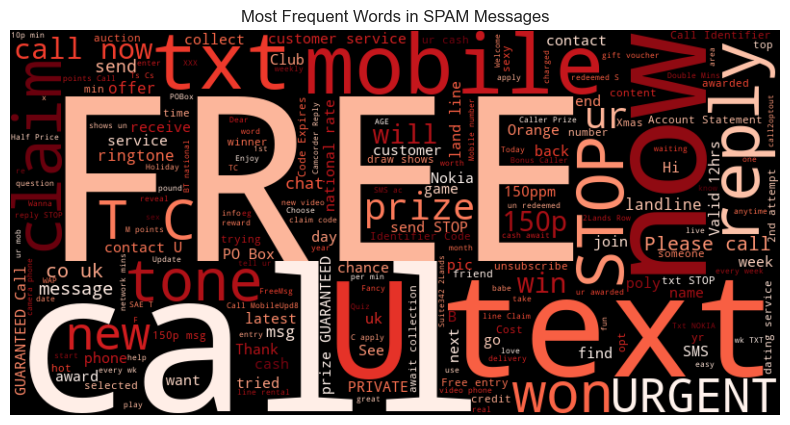

In [11]:
# Generate WordCloud for Spam messages
spam_words = " ".join(df[df['class'] == 'spam']['message'])

wordcloud = WordCloud(width=800, height=400, background_color='black', colormap='Reds').generate(spam_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Most Frequent Words in SPAM Messages")
plt.show()

Cell 8: Top 20 Most Frequent Words (Bar Plot)

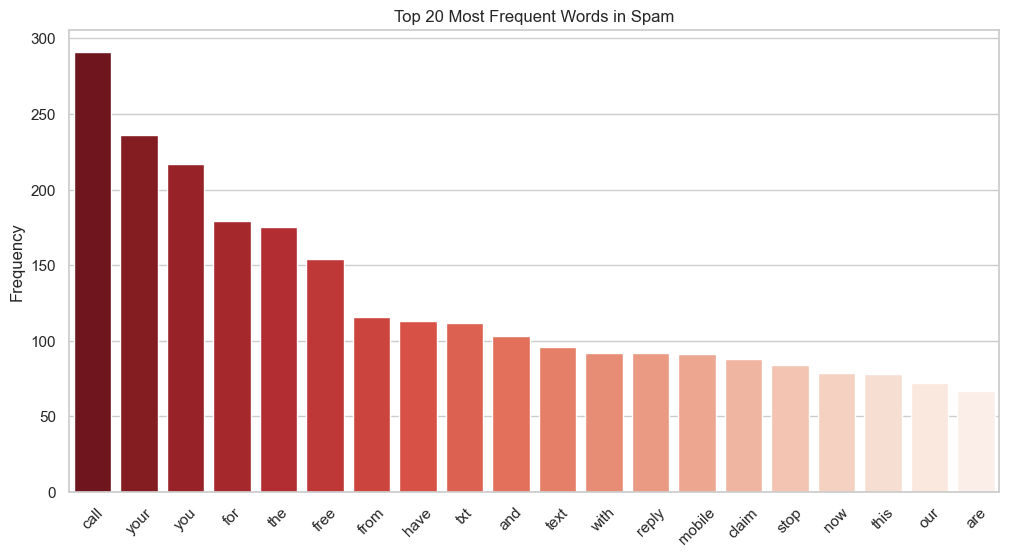

In [12]:
# Helper function to get top words
def get_top_words(text_series, n=20):
    all_words = " ".join(text_series).split()
    # Basic cleaning (optional: you can use your clean_text function here too)
    clean_words = [word.lower() for word in all_words if len(word) > 2]
    return Counter(clean_words).most_common(n)

# Get top words for Spam
top_spam = get_top_words(df[df['class'] == 'spam']['message'])
words, counts = zip(*top_spam)

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(x=list(words), y=list(counts), palette='Reds_r')
plt.title('Top 20 Most Frequent Words in Spam')
plt.xticks(rotation=45)
plt.ylabel('Frequency')
plt.show()

Conclusion & Insights:

Imbalance: The dataset is highly imbalanced (~87% Ham, ~13% Spam). This justifies the use of accuracy alternatives like Recall and F1-Score.

Length Factor: There is a clear distinction in message length. Spam messages generally contain more characters (avg ~138) compared to Ham messages (avg ~70).

Keywords: Words like "FREE", "CALL", "TEXT", "WIN", "PRIZE" are strong indicators of spam. This confirms that a word-frequency based approach (TF-IDF) is suitable for this problem.